# Garmin Race Prediction Analysis

### Introduction
Newer Garmin hardware has been equipped with a race prediction feature which computes race predictions for different distances (5k, 10k, Half Marathon, and Marathon). I have often found myself surprised by how often these predictions accurately represent my current fitness, and how some other times they seem to be far off.\
After having cleaned and engineered numerous datasets, I will proceed by doing a more in depth analysis of my Garmin's race prediction feature. I will sepcifically aim to answer the following questions:
- How did Garmin's race predictions evolve as my training became more consistent and marathon-focused?
- When did Garmin race predictions become more stable?
- Did marathon predictions overshoot actual fitness?

In addition I will be exploring other related trends in Garmin race prediction against observed performance.

### Data & Methodology
This notebook will make use of previously cleaned and engineered datasets derived from my personal Garmin Connect export files. Specifically, I will be working with Garmin race predictions for the 5K, 10K, Half Marathon and Marathon, focusing on the latter since it is my main event. For more details on these datasets, the cleaning performed and additional engineering refer to notebooks 01-07. During the development of this analysis, I manually created an events table to track key training block starts and race dates. This contextual layer allows Garmin prediction trends to be evaluated against real training and racing milestones.

### Imports

In [ ]:
# Necessary imports for exploration
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Helper Functions

In [ ]:
########################
### Helper functions ###
########################

# Data saving helper functions
def to_parquet(df, path):
    """Save a DataFrame to a Parquet file."""
    df.to_parquet(path, index=False)

# Plotting helper functions
def plot_line(df, x_col, y_col, title=None):
    """Plot a line graph of two columns from a DataFrame."""
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x=x_col, y=y_col)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
def plot_line_with_events(events_table, df, prediction, title=None):
    """Plot a line graph with vertical lines for events."""

    # Select races
    race_events = events_table[
        events_table["event_type"] == "race"
    ]

    # Select training block starts ()
    block_events = events_table[
        events_table["event_type"] == "training_block_start"
        ]

    plt.figure(figsize=(12, 6))

    # Prediction curve
    sns.lineplot(
        data=df,
        x='date',
        y=prediction,
        linewidth=2
    )

    # Race markers
    for _, row in race_events.iterrows():
        plt.axvline(
            row["date"],
            color='red',
            linestyle='--',
            alpha=0.6
        )

        plt.text(
            row["date"],
            df[prediction].max(),
            row["label"],
            rotation=90,
            fontsize=8,
            verticalalignment='top'
        )

    # Training block starts
    for _, row in block_events.iterrows():
        plt.axvline(
            row["date"],
            color='green',
            linestyle=':',
            alpha=0.5
        )

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Data frame helper functions
def merge_dataframes_asof(left_df, right_df, left_on, right_on, direction='backward'):
    """Merge two DataFrames using an asof merge."""
    return pd.merge_asof(
        left_df.sort_values(left_on),
        right_df.sort_values(right_on),
        left_on=left_on,
        right_on=right_on,
        direction=direction
    )

# Getter function for relevant prediction
def get_relevant_prediction(row):
    """Get the relevant prediction based on the race type."""
    prediction_map = {
        "5k": "5K_pred",
        "10k": "10K_pred",
        "half": "Half_pred",
        "marathon": "Marathon_pred"
    }
    pred_col = prediction_map.get(row["race_type"])
    if pred_col:
        return row[pred_col]
    return None

### Garmin Race Predictions Over Time

I begin by observing how the Garmin race predictions have evolved since this data began to be collected. Furthermore, I compare the evolution of these predictions with specific training block dates and racing dates with the goal of observing any patterns or specific behavior.

The following visualizations show how Garmin’s race predictions evolved over time across multiple race distances. These predictions are generated internally by Garmin using physiological and training-derived metrics such as VO2 max estimation, training load, and recent performance patterns.

The purpose of this section is to establish a high-level view of how predicted race fitness evolved throughout different phases of training and racing.

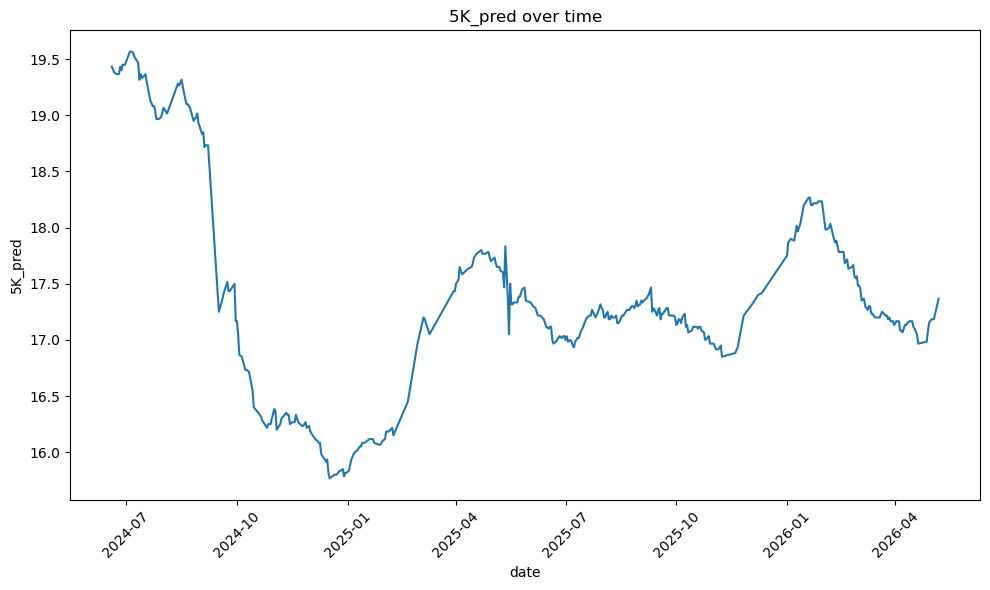

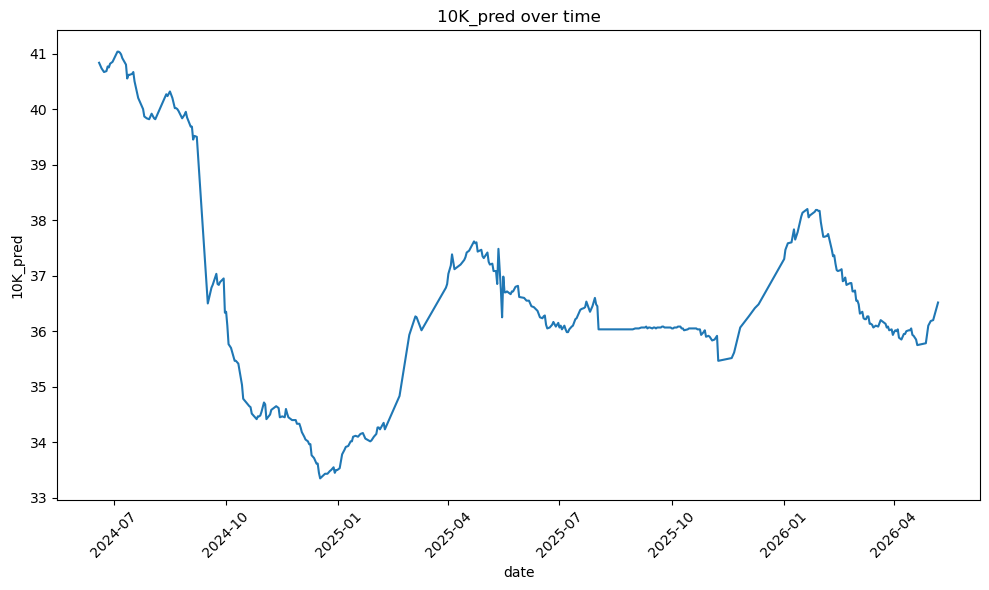

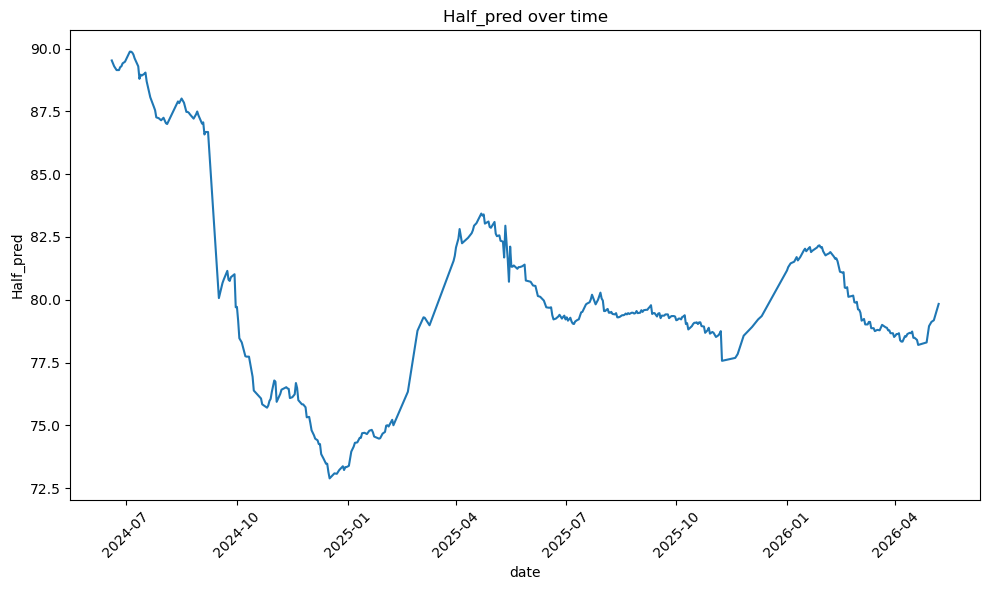

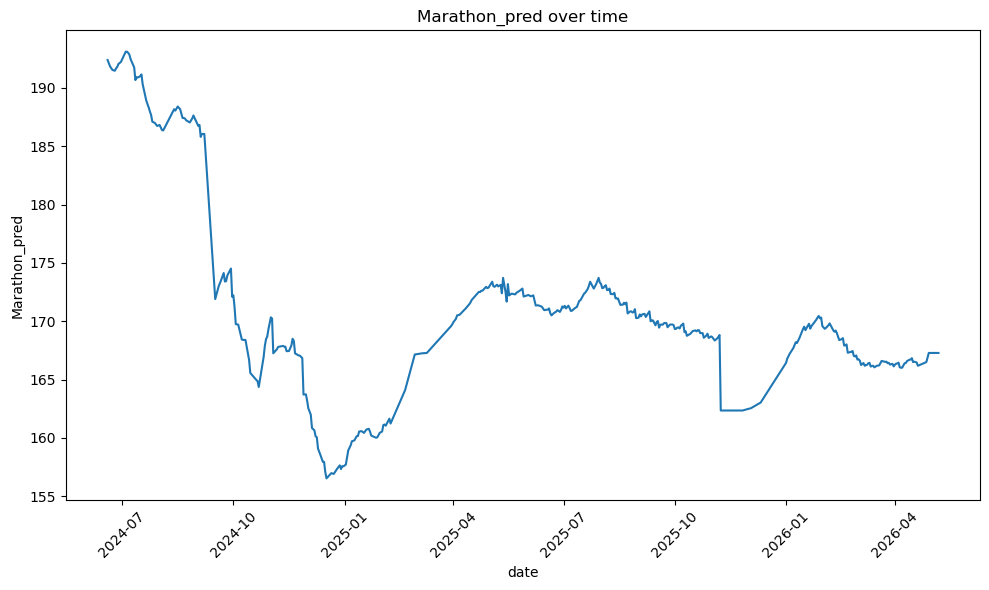

In [37]:
# Looad parquet file into a pandas DataFrame
daily_master_table = pd.read_parquet('/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/daily_master_v1.parquet')

# Replace a bug value of 511 in the 'hrv_weekly_avg_last' column with NaN
daily_master_table["hrv_weekly_avg_clean"] = (
    daily_master_table["hrv_weekly_avg_last"]
    .replace(511, np.nan)
)

# Converting prediction times to seconds in order to be used in analysis
predictions_type = ['5K_pred', '10K_pred', 'Half_pred', 'Marathon_pred']

for prediction in predictions_type:
    daily_master_table[prediction] = pd.to_timedelta(daily_master_table[prediction]) # minutes
    daily_master_table[prediction] = (
    pd.to_timedelta(daily_master_table[prediction])
    .dt.total_seconds() / 60
)
    
# Plot garmin race predictions over time
for prediction in predictions_type: 
    plot_line(daily_master_table, 'date', prediction, title=f'{prediction} over time')

Above we observe plots of Garmin prediction times over time for the four main events. I observe a very fast decline in predicted time during 2024, followed by an aggresive increse from January 2025 to around May 2025. After this it appears as though predicted time stabilizes, resulting in a very interesting pattern of humps. These humps may represent different cycles in my training (off-cycles, training, peaks etc,.). Interestingly these hump structures appear to line up between all four distances, appearing to be more aggresive for 5k and 10k predictions. I am captivated by the intial aggresive dip in prediction time. 

### Overlaying Race Events

To contextualize Garmin’s predictions, major races and training blocks were manually annotated and overlaid onto the prediction timelines. This allows predicted performance trends to be compared against actual race outcomes and important training milestones.


/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_10430/3144137063.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  events_table['date'] = pd.to_datetime(events_table['date'])


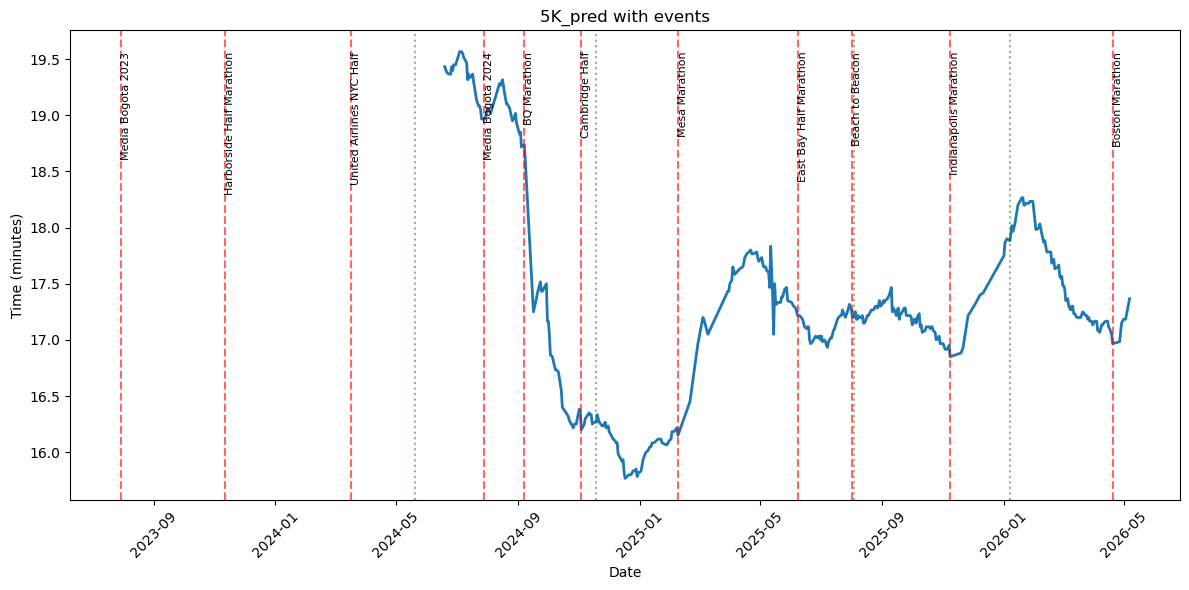

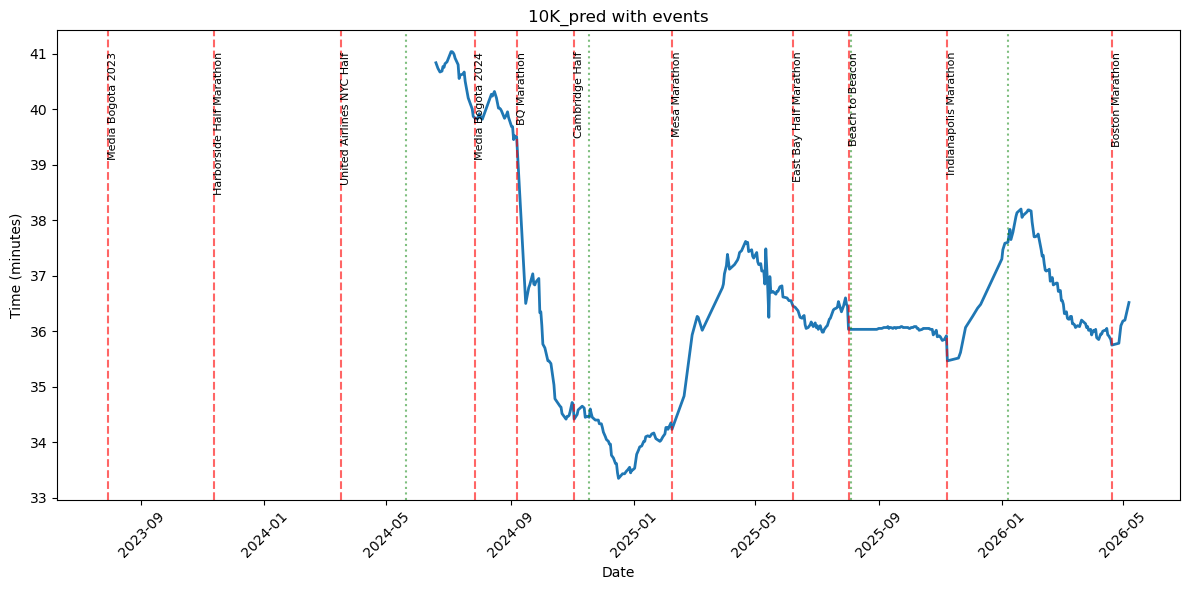

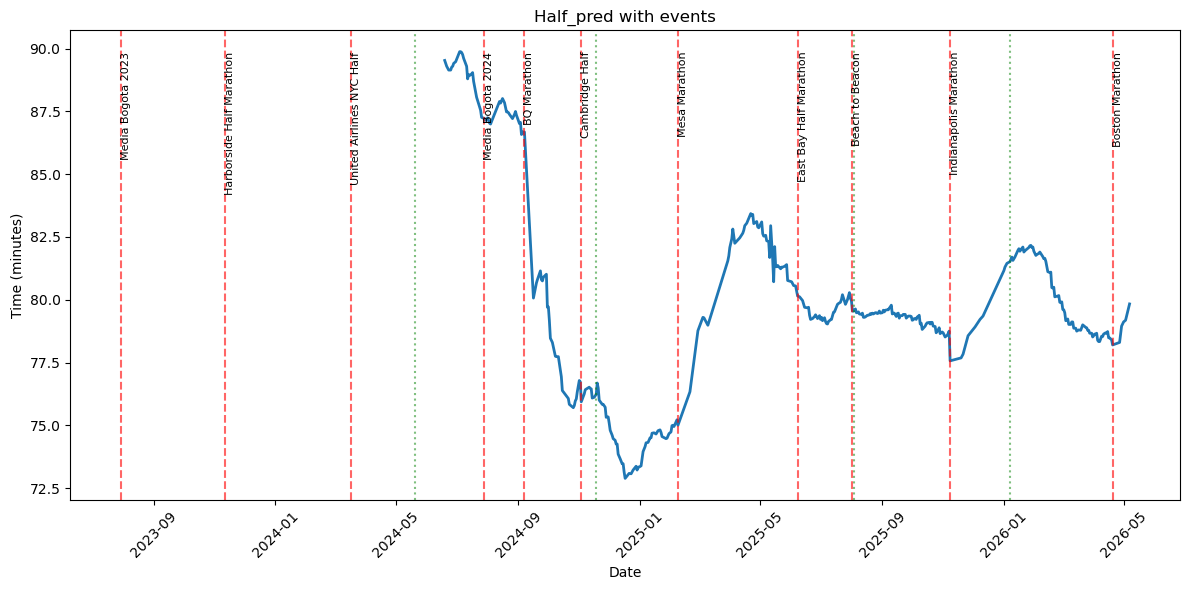

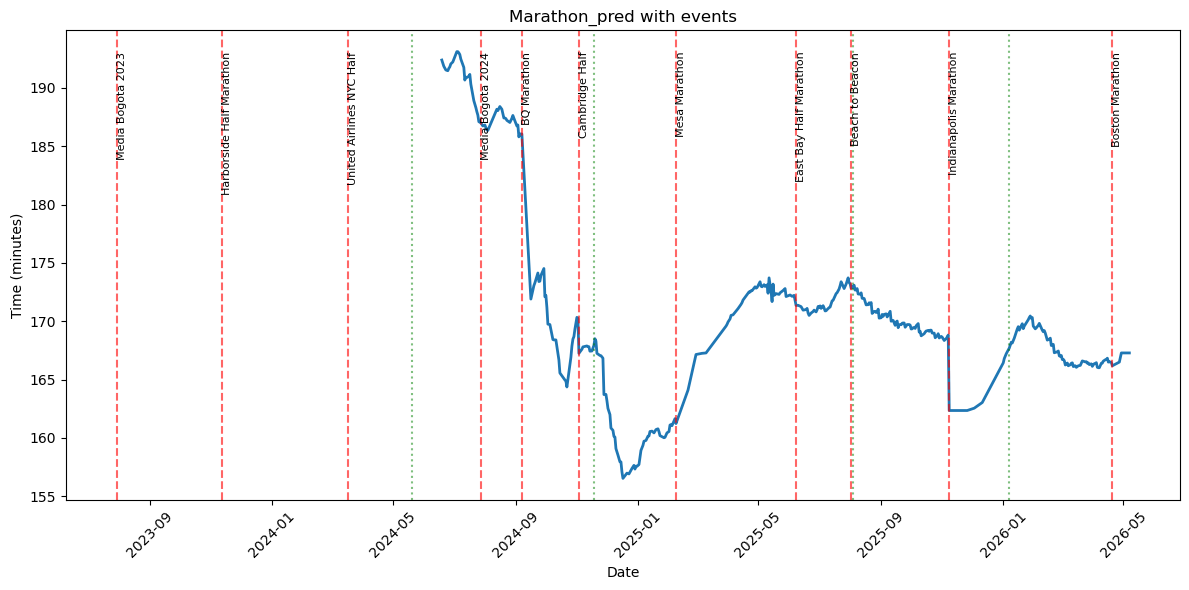

In [53]:
# Load the events table and convert the 'date' column to datetime
events_table = pd.read_csv('/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/events_table.csv')
events_table['date'] = pd.to_datetime(events_table['date'])

# Select races
race_events = events_table[
    events_table["event_type"] == "race"
]

# Select training block starts ()
block_events = events_table[
    events_table["event_type"] == "training_block_start"
    ]

# Plot predictions with race and block start markers
for prediction in predictions_type:
    plot_line_with_events(
        events_table,
        daily_master_table,
        prediction,
        title=f'{prediction} with events'
    )

### Matching Predictions to Race Type

Because Garmin generates predictions for multiple race distances simultaneously (5K, 10K, Half Marathon, and Marathon), each race must be matched to its corresponding prediction type before evaluation.

For example:
- marathon races are evaluated against `Marathon_pred`,
- half marathons against `Half_pred`,
- and so on.

This creates a unified evaluation framework that allows Garmin prediction accuracy to be compared across race events.

When defining `prediction_date` I chose the prediction of the date prior to the race to prevent from any possible data leakage occuring as a result of the race being taken into account when the software makes it's race prediction.

In [ ]:
# Prediction date = day before race
race_events["prediction_date"] = race_events["date"] - pd.Timedelta(days=1)

# Select prediction columns
prediction_cols = [
    "date",
    "5K_pred",
    "10K_pred",
    "Half_pred",
    "Marathon_pred"
]

daily_sorted = daily_master_table.sort_values("date")
race_sorted = race_events.sort_values("prediction_date")

race_prediction_eval_df = merge_dataframes_asof(
    left_df=race_sorted,
    right_df=daily_sorted[prediction_cols],
    left_on="prediction_date",
    right_on="date",
    direction="backward"
)

race_prediction_eval_df = race_prediction_eval_df.rename(
    columns={"date_x": "race_date", "date_y": "prediction_date_matched"}
)

race_prediction_eval_df

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_10430/1175223797.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  race_events["prediction_date"] = race_events["date"] - pd.Timedelta(days=1)


,race_date,event_type,label,official_time_min,race_type,prediction_date,prediction_date_matched,5K_pred,10K_pred,Half_pred,Marathon_pred
0,2023-07-30,race,Media Bogota 2023,119.6300,half,2023-07-29,2023-07-23,NaN,NaN,NaN,NaN
1,2023-11-12,race,Harborside Half Marathon,87.2500,half,2023-11-11,2023-11-11,NaN,NaN,NaN,NaN
2,2024-03-17,race,United Airlines NYC Half,81.6800,half,2024-03-16,2024-03-16,NaN,NaN,NaN,NaN
3,2024-07-28,race,Media Bogota 2024,87.4670,half,2024-07-27,2024-07-26,18.966667,39.866667,87.266667,187.100000
4,2024-09-07,race,BQ Marathon,180.9330,marathon,2024-09-06,2024-09-05,18.733333,39.516667,86.683333,186.050000
5,2024-11-03,race,Cambridge Half,80.3000,half,2024-11-02,2024-11-02,16.366667,34.683333,76.733333,170.233333
6,2025-02-08,race,Mesa Marathon,169.2833,marathon,2025-02-07,2025-02-07,16.216667,34.350000,75.216667,161.650000
7,2025-06-08,race,East Bay Half Marathon,82.3500,half,2025-06-07,2025-06-06,17.283333,36.550000,80.550000,172.216667
8,2025-08-02,race,Beach to Beacon,36.5670,10k,2025-08-01,2025-08-01,17.266667,36.450000,79.966667,173.200000
9,2025-11-08,race,Indianapolis Marathon,164.4800,marathon,2025-11-07,2025-11-07,16.950000,35.916667,78.750000,168.816667


### Prediction Error
Now I will compute prediction error of the races by:
    `prediction_error` = `relevant_pred` - `official_time_min`

This metric will allow me to evaluate statistical trends of the predictions.

In [60]:
# Get the relevant prediction for each race
race_prediction_eval_df["relevant_prediction"] = (
    race_prediction_eval_df.apply(
        get_relevant_prediction,
        axis=1
    )
)

# Compute prediction error
race_prediction_eval_df["prediction_error"] = (
    race_prediction_eval_df["relevant_prediction"]
    - race_prediction_eval_df["official_time_min"]
)

# Display statistics about prediction error
race_prediction_eval_df.groupby("race_type")[
    "prediction_error"
].agg(["mean", "std", "count"])

,mean,std,count
race_type,,,
10k,-0.117000,NaN,1
half,-1.855667,1.683857,3
marathon,-0.573992,6.295077,4


### Official Time vs. Garmin Prediction
The following visualization illustrates where my official race times compare to Garmin's prediction. Each race is represented as a circle. If the circle lies above the dotted line (perfect prediction) then my time was faster than the prediction, conversely, if the circle lies below the dotted line my official time was slower. 

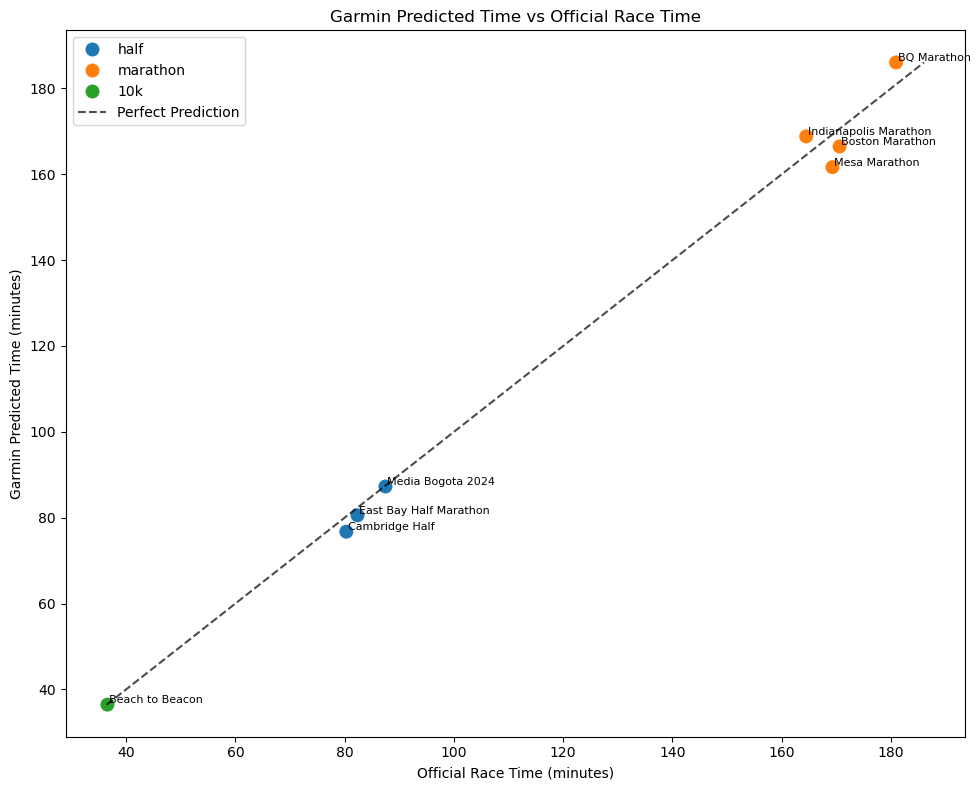

In [61]:
# Plot official time vs predicted time
plt.figure(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=race_prediction_eval_df,
    x="official_time_min",
    y="relevant_prediction",
    hue="race_type",
    s=120
)

# Perfect prediction reference line
min_val = min(
    race_prediction_eval_df["official_time_min"].min(),
    race_prediction_eval_df["relevant_prediction"].min()
)

max_val = max(
    race_prediction_eval_df["official_time_min"].max(),
    race_prediction_eval_df["relevant_prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black",
    alpha=0.7,
    label="Perfect Prediction"
)

# Annotate race names
for _, row in race_prediction_eval_df.iterrows():

    if pd.notna(row["relevant_prediction"]):

        plt.text(
            row["official_time_min"] + 0.3,
            row["relevant_prediction"] + 0.3,
            row["label"],
            fontsize=8
        )

plt.title("Garmin Predicted Time vs Official Race Time")
plt.xlabel("Official Race Time (minutes)")
plt.ylabel("Garmin Predicted Time (minutes)")
plt.legend()
plt.tight_layout()
plt.show()

### Error by Race Type

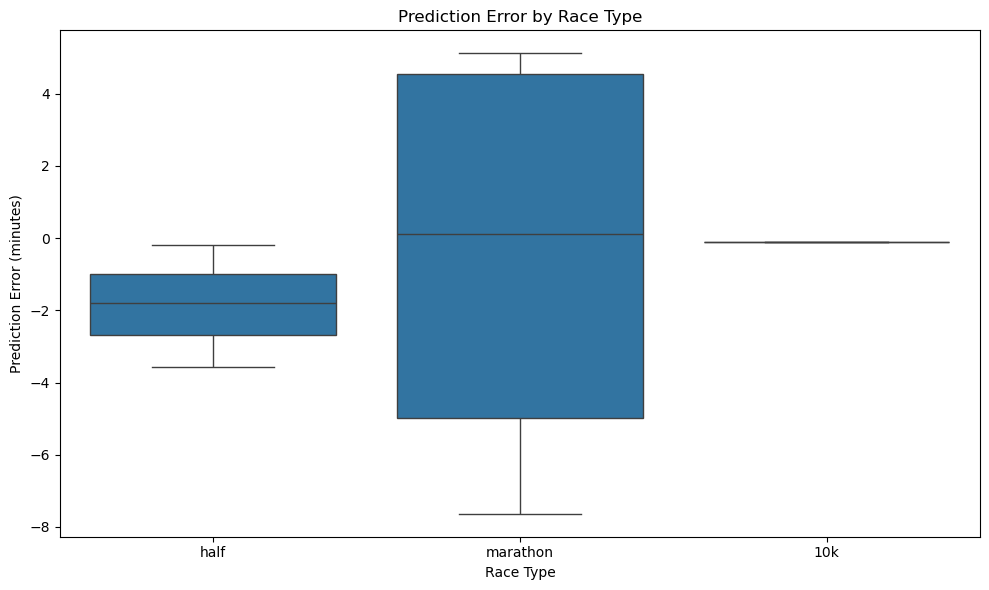

In [15]:
# Compute error by race type and plot boxplot of prediction error
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=race_prediction_eval_df, x="race_type", y="prediction_error")
plt.title("Prediction Error by Race Type")
plt.xlabel("Race Type")
plt.ylabel("Prediction Error (minutes)")
plt.tight_layout()
plt.show()

In [16]:
# optimism/conservatism analysis
race_prediction_eval_df["error_category"] = race_prediction_eval_df["prediction_error"].apply(
    lambda x: "optimistic" if x < 0 else ("conservative" if x > 0 else "neutral"))



# Manually set inidianapolis marathon prediction date to be two days before the race
race_prediction_eval_df["prediction_date_matched"][9] = pd.to_datetime("2025-11-01")
race_prediction_eval_df["prediction_date"][9] = pd.to_datetime("2025-11-01")

print(race_prediction_eval_df)
print(race_prediction_eval_df["error_category"].value_counts())

    race_date event_type                     label  official_time_min  \
0  2023-07-30       race         Media Bogota 2023           119.6300   
1  2023-11-12       race  Harborside Half Marathon            87.2500   
2  2024-03-17       race  United Airlines NYC Half            81.6800   
3  2024-07-28       race         Media Bogota 2024            87.4670   
4  2024-09-07       race               BQ Marathon           180.9330   
5  2024-11-03       race            Cambridge Half            80.3000   
6  2025-02-08       race             Mesa Marathon           169.2833   
7  2025-06-08       race    East Bay Half Marathon            82.3500   
8  2025-08-02       race           Beach to Beacon            36.5670   
9  2025-11-08       race     Indianapolis Marathon           164.4800   
10 2026-04-20       race           Boston Marathon           170.5830   

   race_type prediction_date prediction_date_matched    5K_pred   10K_pred  \
0       half      2023-07-29              202

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_10430/612270696.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  race_prediction_eval_df["prediction_date_matched"][9] = pd.to_datetime("2025-11-01")
/var/folders/5p/042l2mfn5lg_l

My Garmin watch tends to be more optimistic than conservative in gerneral. Furthermore, I have observed that as the distance of the race prediction increases, the prediction error also increases. This suggests that the watch has a harder time predicting times for races such as a marathon and half marathon compared to a 10k. I also want to note that I have not raced many 10ks or 5ks so I want to somehow also analyze harder efforts in training sessions such as tempos and thresholds or unofficial time-trials done outside an organized race.

In [17]:
# Volatility analysis: compute rolling std of predictions in the 7, 15, and 30 days leading up to each race
time_windows = [7, 15, 30]


for time in time_windows:
    daily_master_table[f"rolling_std_{time}_5Kd"] = (
        daily_master_table["5K_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_10Kd"] = (
        daily_master_table["10K_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_Halfd"] = (
        daily_master_table["Half_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_Marathond"] = (
        daily_master_table["Marathon_pred"].rolling(window=time).std()
    )

# print(daily_master_table.filter(like="rolling_std").sample(10))

# A lot of these dates are NaN because of the rolling window, but we can still merge these features into the race_prediction_eval_df for analysis
rolling_cols = [col for col in daily_master_table.columns if "rolling_std" in col]
daily_sorted = daily_master_table.sort_values("date")
race_prediction_eval_df = pd.merge_asof(
    race_prediction_eval_df,
    daily_sorted[["date"] + rolling_cols],
    left_on="prediction_date_matched",
    right_on="date",
    direction="backward"
)
# Run in next cell to avoid merge issues


    race_date event_type                     label  official_time_min  \
0  2023-07-30       race         Media Bogota 2023           119.6300   
1  2023-11-12       race  Harborside Half Marathon            87.2500   
2  2024-03-17       race  United Airlines NYC Half            81.6800   
3  2024-07-28       race         Media Bogota 2024            87.4670   
4  2024-09-07       race               BQ Marathon           180.9330   
5  2024-11-03       race            Cambridge Half            80.3000   
6  2025-02-08       race             Mesa Marathon           169.2833   
7  2025-06-08       race    East Bay Half Marathon            82.3500   
8  2025-08-02       race           Beach to Beacon            36.5670   
9  2025-11-08       race     Indianapolis Marathon           164.4800   
10 2026-04-20       race           Boston Marathon           170.5830   

   race_type prediction_date prediction_date_matched    5K_pred   10K_pred  \
0       half      2023-07-29              202

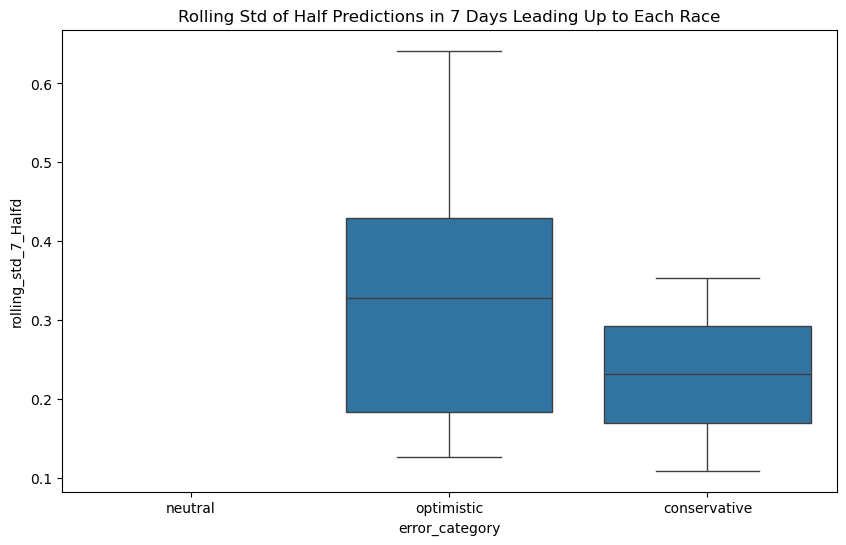

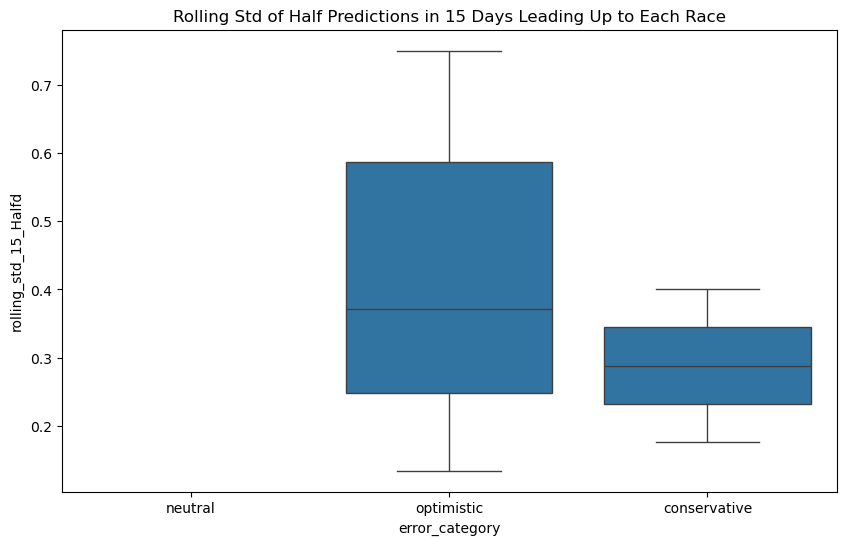

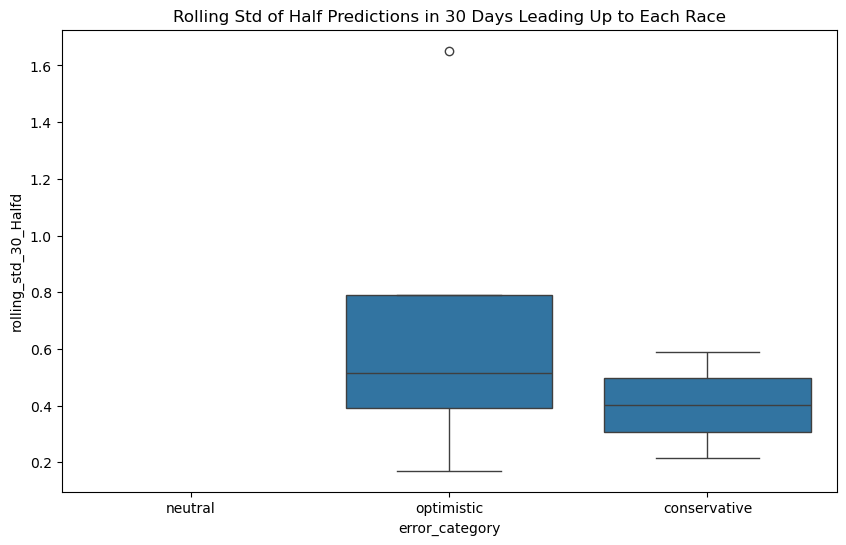

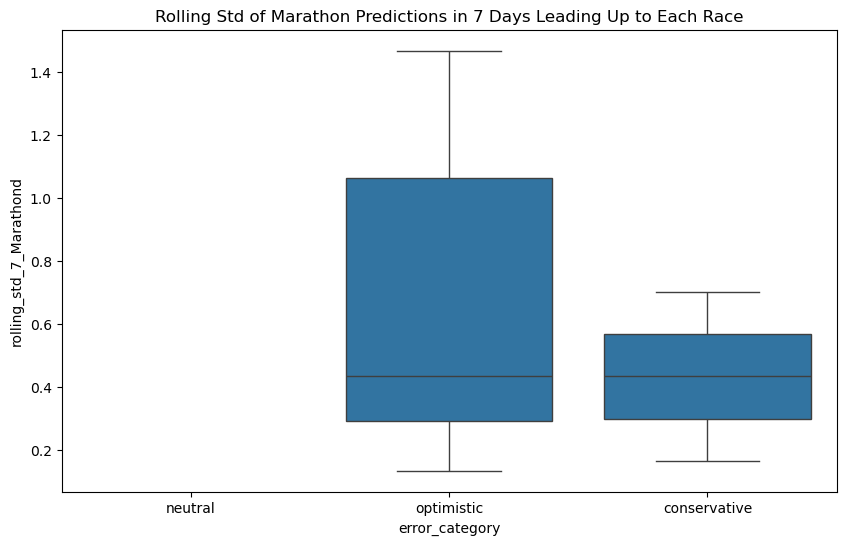

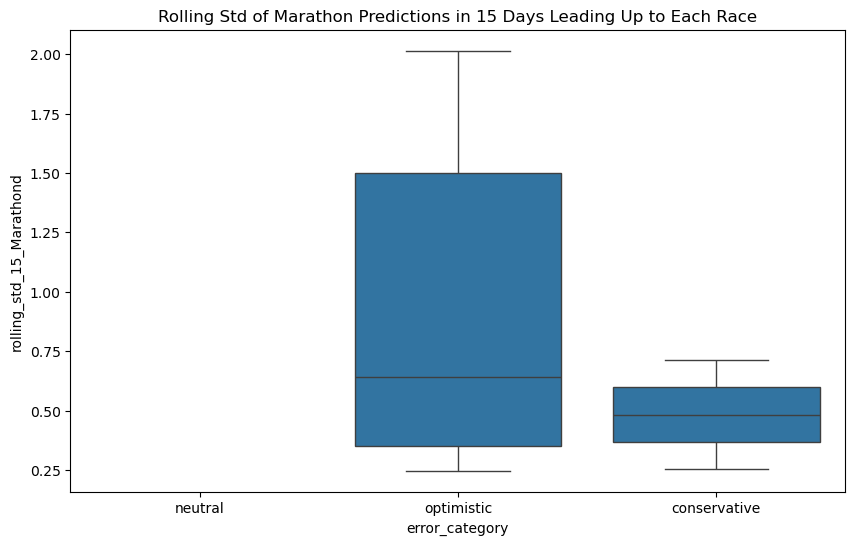

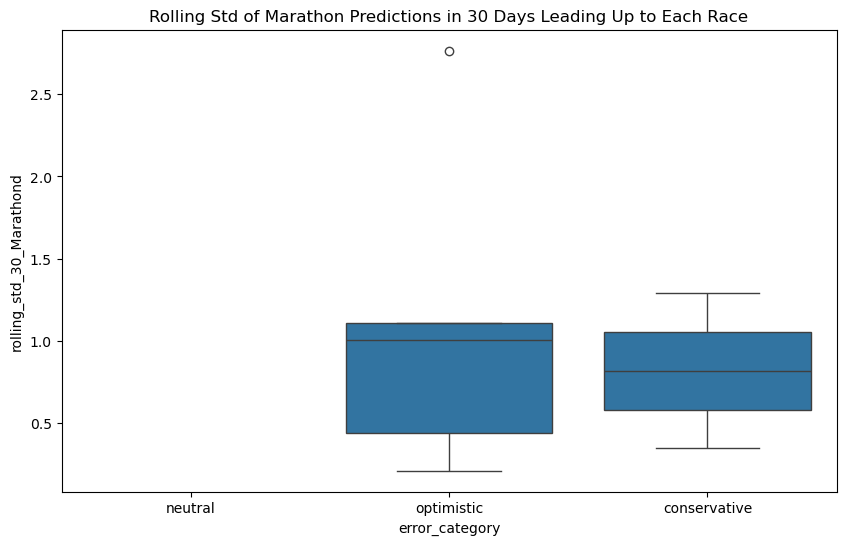

In [18]:
print(race_prediction_eval_df)
# Volatility analysis: compare rolling std of predictions leading up to each race between optimistic and conservative predictions
# Looking at marathon and half predictions since 5k and 10k predictions have a lot of missing values in the rolling std features
for time in time_windows:
    plt.figure(figsize=(10,6))
    sns.boxplot(
        data=race_prediction_eval_df,
        x="error_category",
        y="rolling_std_{}_Halfd".format(time)
    )
    plt.title(f"Rolling Std of Half Predictions in {time} Days Leading Up to Each Race")
    plt.show()

for time in time_windows:
    plt.figure(figsize=(10,6))
    sns.boxplot(
        data=race_prediction_eval_df,
        x="error_category",
        y="rolling_std_{}_Marathond".format(time)
    )
    plt.title(f"Rolling Std of Marathon Predictions in {time} Days Leading Up to Each Race")
    plt.show()

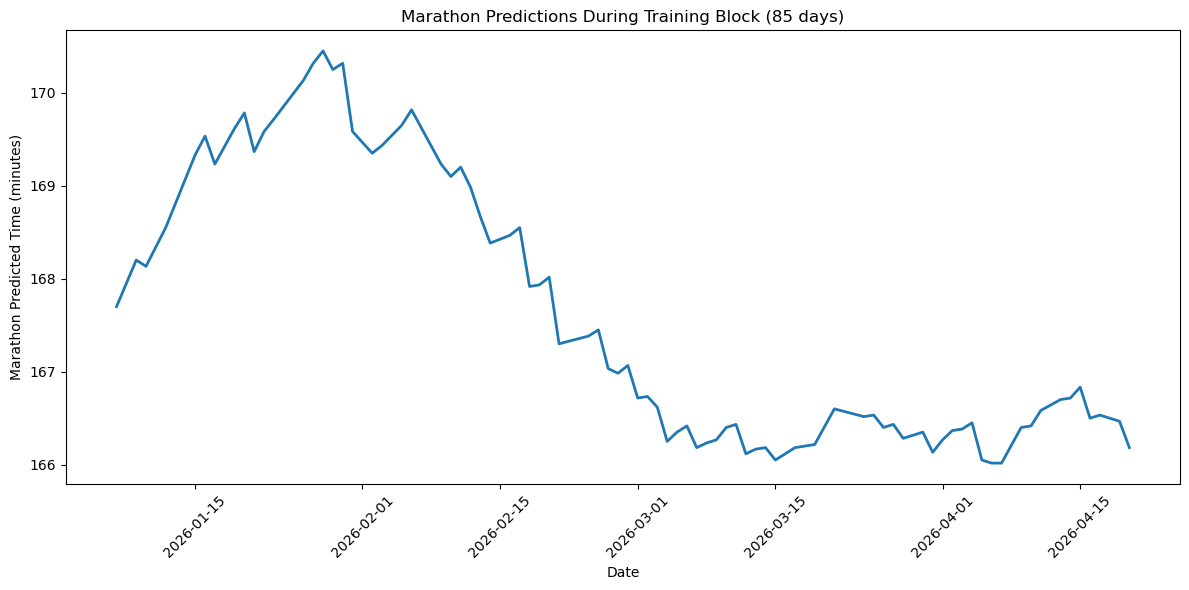

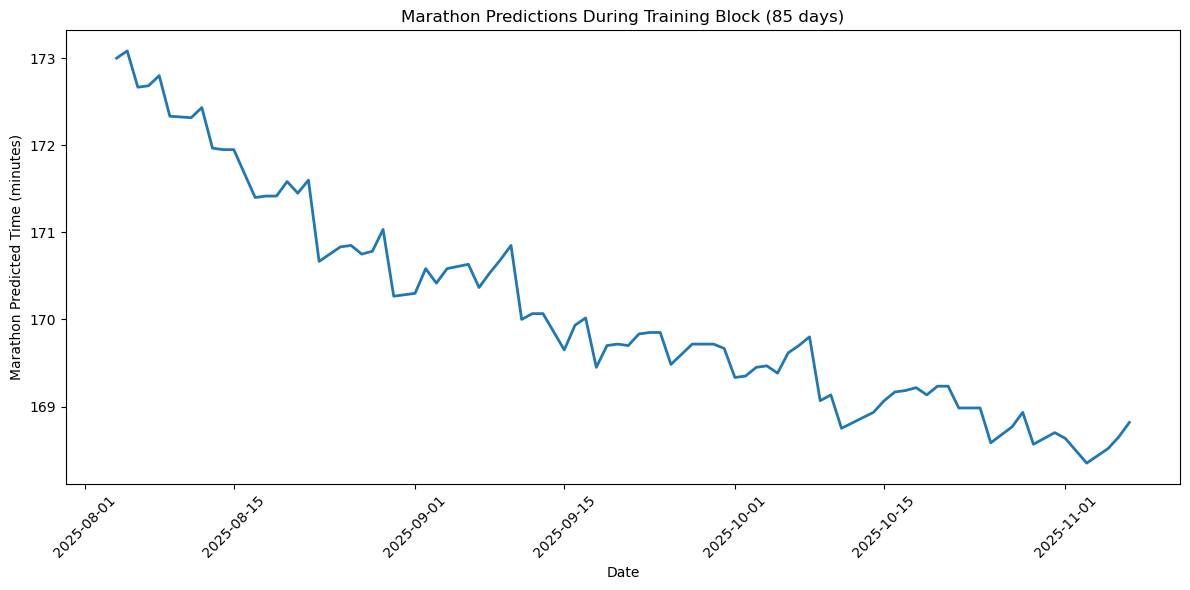

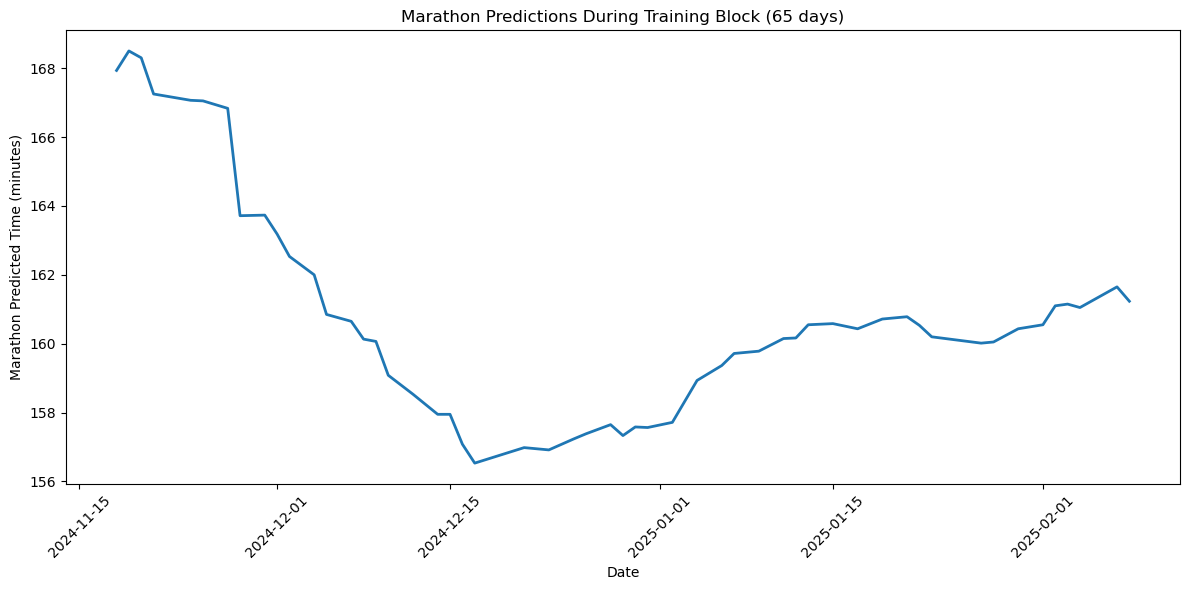

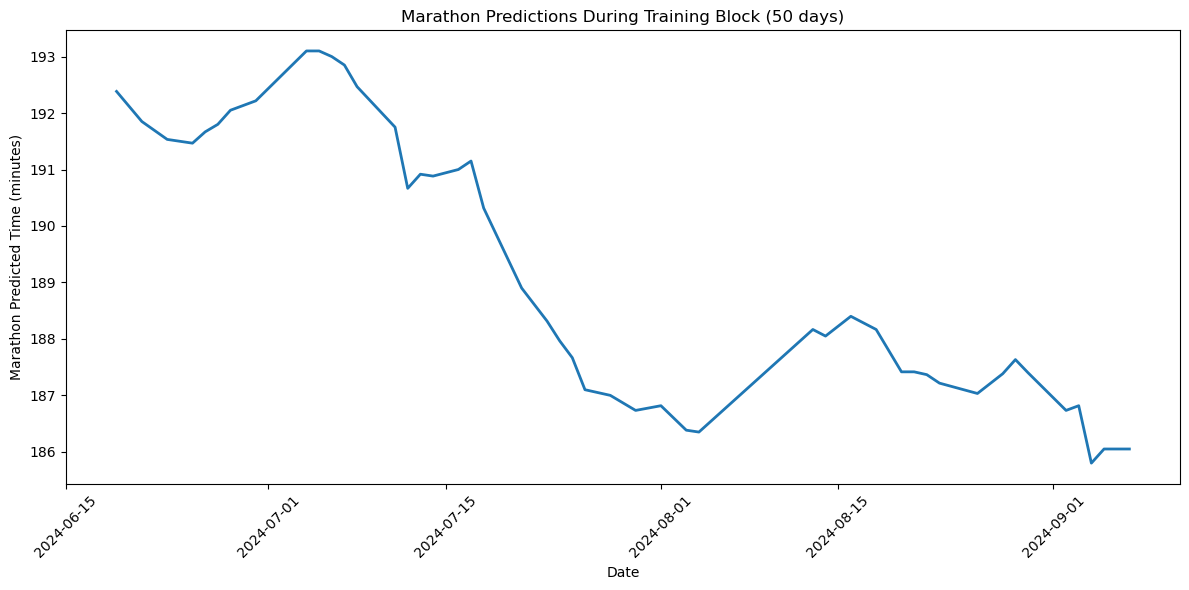

In [19]:
# There exist 4 marathon blocks in the events table
# Create a new dataframe for each marathon block using the dates in the table, manually select the dates
boston_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("2026-01-07")) &
    (daily_master_table["date"] <= pd.to_datetime("2026-04-20"))
]


indianapolis_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("8/4/25")) &
    (daily_master_table["date"] <= pd.to_datetime("11/7/25"))
]

mesa_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("11/18/24")) &
    (daily_master_table["date"] <= pd.to_datetime("2/8/25"))
]

bq_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("2024-06-19")) &
    (daily_master_table["date"] <= pd.to_datetime("9/7/24"))
]

marathon_blocks = [boston_block_daily, indianapolis_block_daily, mesa_block_daily, bq_block_daily]

for block in marathon_blocks:
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=block,
        x='date',
        y='Marathon_pred',
        linewidth=2
    )
    plt.title(f'Marathon Predictions During Training Block ({block.shape[0]} days)')
    plt.xlabel('Date')
    plt.ylabel('Marathon Predicted Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [20]:
# Add information from the race_prediction_eval_df into the marathon block dataframes for further analysis
boston_block_daily = pd.merge_asof(
    boston_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
indianapolis_block_daily = pd.merge_asof(
    indianapolis_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
mesa_block_daily = pd.merge_asof(
    mesa_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
bq_block_daily = pd.merge_asof(
    bq_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)

In [21]:
columns_to_drop = [
    "5K_pred_y",
    "10K_pred_y",
    "Half_pred_y",
    "Marathon_pred_y",
    "rolling_std_7_5Kd_y",
    "rolling_std_15_5Kd_y",
    "rolling_std_30_5Kd_y",
    "rolling_std_7_10Kd_y",
    "rolling_std_15_10Kd_y",
    "rolling_std_30_10Kd_y",
    "rolling_std_7_Halfd_y",
    "rolling_std_15_Halfd_y",
    "rolling_std_30_Halfd_y",
    "rolling_std_7_Marathond_y",
    "rolling_std_15_Marathond_y",
    "rolling_std_30_Marathond_y",
    "5K_pred_x",
    "10K_pred_x",
    "Half_pred_x",
    "rolling_std_7_5Kd_x",
    "rolling_std_15_5Kd_x",
    "rolling_std_30_5Kd_x",
    "rolling_std_7_10Kd_x",
    "rolling_std_15_10Kd_x",
    "rolling_std_30_10Kd_x",
    "rolling_std_7_Halfd_x",
    "rolling_std_15_Halfd_x",
    "rolling_std_30_Halfd_x",
]

boston_block_daily = boston_block_daily.drop(columns=columns_to_drop)
indianapolis_block_daily = indianapolis_block_daily.drop(columns=columns_to_drop)
mesa_block_daily = mesa_block_daily.drop(columns=columns_to_drop)  
bq_block_daily = bq_block_daily.drop(columns=columns_to_drop)

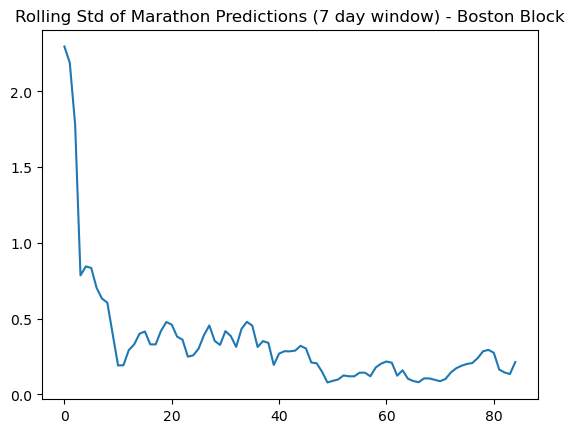

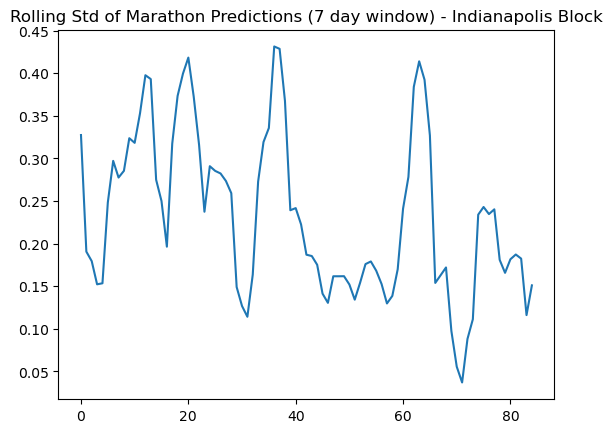

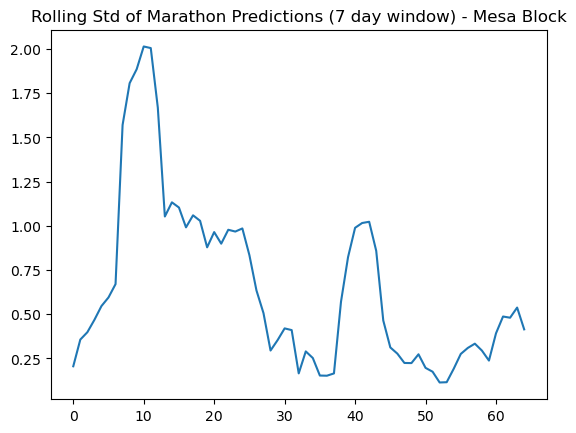

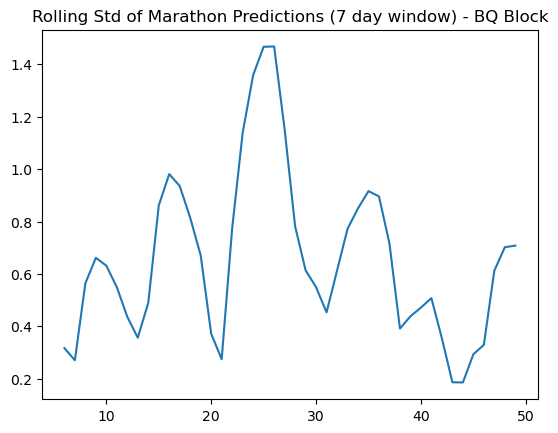

In [22]:
# Determine when predictions start to become more stable (less volatile) using the rolling std features in the marathon blocks
boston_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Boston Block")
plt.show()

indianapolis_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Indianapolis Block")
plt.show()

mesa_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Mesa Block")
plt.show()

bq_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - BQ Block")
plt.show()

### Rolling Prediction Volatility Across Marathon Blocks

The rolling standard deviation plots reveal that Garmin marathon prediction behavior varies substantially across different training blocks. Rather than following a single consistent pattern, each block appears to exhibit its own distinct prediction dynamics.

Several observations stand out immediately:

- The Indianapolis Marathon block appears relatively stable throughout most of the training cycle, with consistently low rolling volatility. Interestingly, this block also resulted in the strongest marathon performance in the dataset.
  
- The Mesa Marathon block shows significantly higher volatility, including multiple abrupt spikes and large fluctuations in predicted marathon fitness. This same block also produced Garmin’s largest optimistic prediction error relative to the official race result.

- The Boston Marathon block demonstrates an initial adaptation period followed by a long phase of remarkably low volatility, suggesting that Garmin’s prediction system may have converged on a stable estimate of fitness late in the cycle.

- The BQ Marathon block displays repeated oscillatory behavior, with several cycles of increasing and decreasing volatility. This may indicate that Garmin repeatedly reevaluated fitness status throughout the build.

These results suggest that the *dynamics* of Garmin race predictions may be just as important as the final predicted value itself. In particular, prediction stability and volatility may provide insight into:
- training consistency,
- physiological adaptation,
- model confidence,
- or uncertainty in estimated marathon fitness.

At this stage, no definitive conclusions are being made. However, the differences between marathon blocks suggest that prediction volatility may be a meaningful signal worth investigating further.

In [23]:
print(boston_block_daily.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 60 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            85 non-null     datetime64[ns]
 1   run_count                       85 non-null     int64         
 2   total_distance_km               85 non-null     float64       
 3   total_distance_miles            85 non-null     float64       
 4   total_duration_minutes          85 non-null     float64       
 5   total_moving_minutes            85 non-null     float64       
 6   total_elevation_gain_m          85 non-null     float64       
 7   avg_hr                          85 non-null     float64       
 8   max_hr                          85 non-null     float64       
 9   avg_pace_mile                   85 non-null     float64       
 10  avg_power                       85 non-null     float64       
 11  max_powe

In [24]:
boston_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/boston_block_daily_v1.parquet',
    index=False
)

indianapolis_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/indianapolis_block_daily_v1.parquet',
    index=False
)

mesa_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/mesa_block_daily_v1.parquet',
    index=False
)

bq_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/bq_block_daily_v1.parquet',
    index=False
)

In [25]:
print(daily_master_table.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 62 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            753 non-null    datetime64[ns]
 1   run_count                       753 non-null    int64         
 2   total_distance_km               753 non-null    float64       
 3   total_distance_miles            753 non-null    float64       
 4   total_duration_minutes          753 non-null    float64       
 5   total_moving_minutes            753 non-null    float64       
 6   total_elevation_gain_m          753 non-null    float64       
 7   avg_hr                          738 non-null    float64       
 8   max_hr                          738 non-null    float64       
 9   avg_pace_mile                   753 non-null    float64       
 10  avg_power                       422 non-null    float64       
 11  max_po

In [26]:
print(boston_block_daily.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 60 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            85 non-null     datetime64[ns]
 1   run_count                       85 non-null     int64         
 2   total_distance_km               85 non-null     float64       
 3   total_distance_miles            85 non-null     float64       
 4   total_duration_minutes          85 non-null     float64       
 5   total_moving_minutes            85 non-null     float64       
 6   total_elevation_gain_m          85 non-null     float64       
 7   avg_hr                          85 non-null     float64       
 8   max_hr                          85 non-null     float64       
 9   avg_pace_mile                   85 non-null     float64       
 10  avg_power                       85 non-null     float64       
 11  max_powe

In [28]:
# Create a block summary table with the following columns:
# block_name
# race_date
# actual_time
# final_prediction
# prediction_error (final_prediction - actual_time)
# prediction_bias (optimistic / neutral / conservative) where optimistic if error < -2 min, neutral if between -2 and +2, conservative if error > +2
# mean_volatility
# max_volatility
# stable_date
# days_stable_before_race
# peak_weekly_mileage
# avg_weekly_mileage
# last_14_day_avg_prediction
# prediction_drift
# avg_training_load
# avg_readiness
# vo2_drift
# avg_hrv


block_dict = {
    "BQ Marathon": bq_block_daily,
    "Mesa Marathon": mesa_block_daily,
    "Indianapolis Marathon": indianapolis_block_daily,
    "Boston Marathon": boston_block_daily
}

summary_rows = []

for block_name, df in block_dict.items():

    df = df.sort_values("date").reset_index(drop=True)

    # -----------------------------
    # Race row from evaluation df
    # -----------------------------
    race_row = race_prediction_eval_df[
        race_prediction_eval_df["label"].str.contains(
            block_name.split()[0],
            case=False,
            na=False
        )
    ].iloc[0]

    race_date = race_row["race_date"]
    actual_time = race_row["official_time_min"]
    final_prediction = race_row["relevant_prediction"]

    # -----------------------------
    # Prediction error
    # -----------------------------
    prediction_error = final_prediction - actual_time

    if prediction_error < -2:
        prediction_bias = "optimistic"
    elif prediction_error > 2:
        prediction_bias = "conservative"
    else:
        prediction_bias = "neutral"

    # -----------------------------
    # Volatility metrics
    # -----------------------------
    mean_volatility = df["rolling_std_7_Marathond_x"].mean()
    max_volatility = df["rolling_std_7_Marathond_x"].max()

    # -----------------------------
    # Stability logic
    # Define stable as:
    # within ±2 min of final prediction
    # -----------------------------
    tolerance = 2

    stable_mask = (
        (df["Marathon_pred_x"] - final_prediction)
        .abs()
        <= tolerance
    )

    stable_date = pd.NaT

    for i in range(len(df)):
        remaining = stable_mask.iloc[i:]

        if remaining.all():
            stable_date = df.iloc[i]["date"]
            break

    if pd.notnull(stable_date):
        days_stable_before_race = (
            pd.to_datetime(race_date) - stable_date
        ).days
    else:
        days_stable_before_race = np.nan

    # -----------------------------
    # Weekly mileage
    # -----------------------------
    weekly_mileage = (
        df
        .set_index("date")["total_distance_miles"]
        .resample("W")
        .sum()
    )

    peak_weekly_mileage = weekly_mileage.max()
    avg_weekly_mileage = weekly_mileage.mean()

    # -----------------------------
    # Last 14 day avg prediction
    # -----------------------------
    last_14_day_avg_prediction = (
        df.tail(14)["Marathon_pred_x"].mean()
    )

    # -----------------------------
    # Prediction drift
    # -----------------------------
    prediction_drift = (
        final_prediction
        - df["Marathon_pred_x"].iloc[0]
    )

    # -----------------------------
    # Avg training load
    # -----------------------------
    avg_training_load = (
        df["total_training_load"].mean()
    )

    # -----------------------------
    # Avg readiness
    # -----------------------------
    avg_readiness = (
        df["readiness_score_mean"].mean()
    )

    # -----------------------------
    # VO2 drift
    # -----------------------------
    vo2_drift = (
        df["vo2MaxValue"].iloc[-1]
        - df["vo2MaxValue"].iloc[0]
    )

    # -----------------------------
    # Avg HRV
    # -----------------------------
    avg_hrv = (
        df["hrv_weekly_avg_clean"].mean()
    )

    # -----------------------------
    # Append row
    # -----------------------------
    summary_rows.append({
        "block_name": block_name,
        "race_date": race_date,
        "actual_time": actual_time,
        "final_prediction": final_prediction,
        "prediction_error": prediction_error,
        "prediction_bias": prediction_bias,
        "mean_volatility": mean_volatility,
        "max_volatility": max_volatility,
        "stable_date": stable_date,
        "days_stable_before_race": days_stable_before_race,
        "peak_weekly_mileage": peak_weekly_mileage,
        "avg_weekly_mileage": avg_weekly_mileage,
        "last_14_day_avg_prediction": last_14_day_avg_prediction,
        "prediction_drift": prediction_drift,
        "avg_training_load": avg_training_load,
        "avg_readiness": avg_readiness,
        "vo2_drift": vo2_drift,
        "avg_hrv": avg_hrv
    })

summary_table = pd.DataFrame(summary_rows)

print(summary_table)

              block_name  race_date  actual_time  final_prediction  \
0            BQ Marathon 2024-09-07     180.9330        186.050000   
1          Mesa Marathon 2025-02-08     169.2833        161.650000   
2  Indianapolis Marathon 2025-11-08     164.4800        168.816667   
3        Boston Marathon 2026-04-20     170.5830        166.466667   

   prediction_error prediction_bias  mean_volatility  max_volatility  \
0          5.117000    conservative         0.656393        1.468019   
1         -7.633300      optimistic         0.653696        2.014918   
2          4.336667    conservative         0.232336        0.431345   
3         -4.116333      optimistic         0.347469        2.296109   

  stable_date  days_stable_before_race  peak_weekly_mileage  \
0  2024-08-20                       18            75.136621   
1  2025-01-07                       32            90.046417   
2  2025-09-11                       58            91.732904   
3  2026-02-18                       

### Preliminary Block-Level Findings

Several meaningful differences emerge when comparing marathon training blocks at an aggregate level.

The Indianapolis Marathon block exhibited the lowest prediction volatility by a substantial margin, while also corresponding to the strongest marathon performance and highest sustained mileage in the dataset. In contrast, the Mesa Marathon block displayed significantly higher volatility and Garmin’s largest optimistic prediction error.

Interestingly, both the Boston and Indianapolis blocks stabilized far earlier than the BQ block, suggesting that Garmin’s prediction system may become more confident during mature or highly consistent training cycles. (Also more running experience)

Prediction bias was not uniform across races. Garmin alternated between optimistic and conservative behavior depending on the block, suggesting that prediction dynamics may depend heavily on training structure, fatigue state, or adaptation patterns rather than a simple systematic bias.

These findings remain exploratory, but they suggest that prediction volatility and stabilization behavior may provide meaningful signals beyond the final race prediction itself.

In [29]:
# === Scratch paper ===


Preliminary Findings
- Garmin marathon predictions exhibit substantially more volatility than shorter-distance predictions.
- Prediction leakage exists on race days.
- Indianapolis showed the most stable prediction dynamics and corresponded with the strongest marathon result.
- Mesa exhibited the highest volatility and largest optimistic prediction error.

Dedicated Findings Section

Limitations Section

Figures: Marathon perdiction evolution over block, rolling volatility comparison across blocks, block summary comparison table, prediction stabilization visualization,